# 멀티모달 Cross-Attention Fusion
Video × Text × Audio 를 Cross-Attention으로 퓨전하여 감정 이진 분류수행

| 모달 | 파일 | 차원 |
|------|------|------|
| Video | `data/video_features_256.pkl` | 256 |
| Text  | `data/text_features_256(basic+earlystop).pkl` | 256 |
| Audio | `data/audio_feat_hubert_origin.pkl` | 256 |

> **pkl 파일 위치 안내**  
> - Text: sooyeon 브랜치의 `text_features_256(basic+earlystop).pkl` → `data/` 폴더에 복사  
> - Audio: jeein 브랜치의 `audio/audio_feat_hubert_origin.pkl` → `data/` 폴더에 복사

In [28]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


## 1. 피처 로드 & 샘플 정렬

- **Video**: `feat_dict` 포맷 — sample key 기준으로 정렬  
- **Text / Audio**: 기존 인덱스 포맷 — CSV 저장 순서 그대로 로드  
- 세 모달리티가 동일한 원본 CSV 순서로 저장됐다는 전제 (정렬 후 P/N 분포로 검증)

In [29]:
VIDEO_PKL = 'data/video_features_256.pkl'
TEXT_PKL  = 'data/text_features_256(basic+earlystop).pkl'
AUDIO_PKL = 'data/audio_feat_hubert_origin.pkl'

# ── Video: feat_dict 포맷 ─────────────────────────────────────────────────────
with open(VIDEO_PKL, 'rb') as f:
    video_raw = pickle.load(f)
vid_feats = video_raw['features']
vid_lbl   = video_raw['labels']

# ── Text / Audio: 기존 인덱스 포맷 ───────────────────────────────────────────
def load_index_pkl(path):
    """{"features": tensor, "labels": tensor} 또는 torch.save 포맷."""
    try:
        with open(path, 'rb') as f:
            data = pickle.load(f)
    except Exception:
        data = torch.load(path, map_location='cpu', weights_only=False)
    label_key = next(k for k in data if 'label' in k.lower())
    feat_key  = next(k for k in data if 'label' not in k.lower())
    feats  = data[feat_key]
    labels = data[label_key]
    if not isinstance(feats,  torch.Tensor): feats  = torch.tensor(np.array(feats),  dtype=torch.float32)
    if not isinstance(labels, torch.Tensor): labels = torch.tensor(np.array(labels), dtype=torch.long)
    return feats.float(), labels.long()

text_feats,  text_lbl  = load_index_pkl(TEXT_PKL)
audio_feats, audio_lbl = load_index_pkl(AUDIO_PKL)

print(f'Video  : {vid_feats.shape}')
print(f'Text   : {text_feats.shape}')
print(f'Audio  : {audio_feats.shape}')

Video  : torch.Size([2199, 256])
Text   : torch.Size([2199, 256])
Audio  : torch.Size([2199, 256])


## 2. 레이블 진단 & Ground Truth 결정

In [30]:
assert vid_feats.shape[0] == text_feats.shape[0] == audio_feats.shape[0], \
    f'샘플 수 불일치! Video={vid_feats.shape[0]}, Text={text_feats.shape[0]}, Audio={audio_feats.shape[0]}'

# ── Positive / Negative 분포 비교 ─────────────────────────────────────────────
print(f'{"":10} {"Positive(1)":>12} {"Negative(0)":>12}')
print('─' * 36)
for name, lbl in [('Video', vid_lbl), ('Text', text_lbl), ('Audio', audio_lbl)]:
    print(f'{name:<10} {(lbl==1).sum().item():>12,} {(lbl==0).sum().item():>12,}')

# ── 레이블 일치율 ──────────────────────────────────────────────────────────────
vt = (vid_lbl == text_lbl).float().mean().item()
va = (vid_lbl == audio_lbl).float().mean().item()
ta = (text_lbl == audio_lbl).float().mean().item()
print(f'\n레이블 일치율:')
print(f'  Video  vs Text  : {vt*100:.1f}%  {"✅" if vt==1. else "❌"}')
print(f'  Video  vs Audio : {va*100:.1f}%  {"✅" if va==1. else "❌"}')
print(f'  Text   vs Audio : {ta*100:.1f}%  {"✅" if ta==1. else "❌"}')

# ── Ground truth 결정 ─────────────────────────────────────────────────────────
if ta == 1.0:
    labels = text_lbl;  gt_src = 'Text = Audio'
elif vt == 1.0:
    labels = vid_lbl;   gt_src = 'Video = Text'
elif va == 1.0:
    labels = vid_lbl;   gt_src = 'Video = Audio'
else:
    labels = text_lbl if ta >= vt else vid_lbl
    gt_src = f'{"Text" if ta>=vt else "Video"} (⚠ 완전 일치 없음)'

print(f'\n→ Ground truth: {gt_src}  |  Positive: {(labels==1).sum().item()}  Negative: {(labels==0).sum().item()}')

            Positive(1)  Negative(0)
────────────────────────────────────
Video             1,080        1,119
Text              1,080        1,119
Audio             1,080        1,119

레이블 일치율:
  Video  vs Text  : 100.0%  ✅
  Video  vs Audio : 100.0%  ✅
  Text   vs Audio : 100.0%  ✅

→ Ground truth: Text = Audio  |  Positive: 1080  Negative: 1119


In [31]:
# ── Train / Val / Test 분할 (7:1.5:1.5, stratified) ──────────────────────────
labels_np = labels.numpy()
idx = np.arange(len(labels_np))

tr_idx, te_idx = train_test_split(idx, test_size=0.3,  random_state=SEED, stratify=labels_np)
te_idx, va_idx = train_test_split(te_idx, test_size=0.5, random_state=SEED, stratify=labels_np[te_idx])

print(f'Train: {len(tr_idx)}  Val: {len(va_idx)}  Test: {len(te_idx)}')

def make_loader(idx_arr, shuffle=False):
    v = vid_feats[idx_arr].to(device)
    t = text_feats[idx_arr].to(device)
    a = audio_feats[idx_arr].to(device)
    y = labels[idx_arr].to(device)
    return DataLoader(TensorDataset(v, t, a, y), batch_size=32, shuffle=shuffle)

train_loader = make_loader(tr_idx, shuffle=True)
val_loader   = make_loader(va_idx)
test_loader  = make_loader(te_idx)

Train: 1539  Val: 330  Test: 330


## 3. 모델 정의 — Cross-Attention Fusion

```
Video(256) ─┐
Text (256) ─┼─► CrossAttn(V→T,A) + CrossAttn(T→V,A) + CrossAttn(A→V,T) ─► concat(768) ─► MLP ─► 2
Audio(256) ─┘
```

각 모달리티가 나머지 두 모달리티에 대해 **Query → (Key, Value)** Cross-Attention을 수행합니다.

In [32]:
class CrossAttention(nn.Module):
    """단일 Cross-Attention 블록.
    query: (B, D_q)  key/value: (B, N_kv, D_kv)
    out:   (B, D_q)
    """
    def __init__(self, d_query: int, d_kv: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim=d_query, num_heads=num_heads,
            kdim=d_kv, vdim=d_kv,
            batch_first=True, dropout=dropout
        )
        self.norm = nn.LayerNorm(d_query)
        self.ff   = nn.Sequential(
            nn.Linear(d_query, d_query * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_query * 2, d_query),
        )
        self.norm2 = nn.LayerNorm(d_query)

    def forward(self, query, kv):
        """query: (B, D)  kv: (B, 2, D) — 두 모달리티를 sequence로 쌓아서 넣음"""
        q = query.unsqueeze(1)              # (B, 1, D)
        attn_out, _ = self.mha(q, kv, kv)  # (B, 1, D)
        attn_out = attn_out.squeeze(1)      # (B, D)
        x = self.norm(query + attn_out)     # residual
        x = self.norm2(x + self.ff(x))      # FF + residual
        return x


class TriModalCrossAttnFusion(nn.Module):
    """
    Video(v), Text(t), Audio(a) 세 모달리티를 Cross-Attention으로 퓨전.

    각 모달리티가 나머지 두를 attend:
      v' = CrossAttn(Q=v, KV=[t, a])
      t' = CrossAttn(Q=t, KV=[v, a])
      a' = CrossAttn(Q=a, KV=[v, t])

    최종: concat([v', t', a']) → MLP → logits
    """
    def __init__(self, feat_dim: int = 256, num_heads: int = 4,
                 dropout: float = 0.1, num_classes: int = 2):
        super().__init__()
        # 입력 정규화 (각 모달리티의 피처 스케일 통일)
        self.ln_v = nn.LayerNorm(feat_dim)
        self.ln_t = nn.LayerNorm(feat_dim)
        self.ln_a = nn.LayerNorm(feat_dim)

        # Cross-Attention: 각 모달리티 → 나머지 두 모달리티
        self.ca_v = CrossAttention(feat_dim, feat_dim, num_heads, dropout)  # v attends (t,a)
        self.ca_t = CrossAttention(feat_dim, feat_dim, num_heads, dropout)  # t attends (v,a)
        self.ca_a = CrossAttention(feat_dim, feat_dim, num_heads, dropout)  # a attends (v,t)

        # 분류 헤드
        fused_dim = feat_dim * 3  # 256 × 3 = 768
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, v, t, a):
        """v, t, a: (B, 256)"""
        v = self.ln_v(v)
        t = self.ln_t(t)
        a = self.ln_a(a)

        # KV: 두 모달리티를 sequence 차원으로 묶음 (B, 2, 256)
        kv_for_v = torch.stack([t, a], dim=1)  # video가 볼 context
        kv_for_t = torch.stack([v, a], dim=1)  # text가 볼 context
        kv_for_a = torch.stack([v, t], dim=1)  # audio가 볼 context

        v_out = self.ca_v(v, kv_for_v)  # (B, 256)
        t_out = self.ca_t(t, kv_for_t)  # (B, 256)
        a_out = self.ca_a(a, kv_for_a)  # (B, 256)

        fused  = torch.cat([v_out, t_out, a_out], dim=-1)  # (B, 768)
        logits = self.classifier(fused)                     # (B, 2)
        return logits


model = TriModalCrossAttnFusion(feat_dim=256, num_heads=4, dropout=0.2).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n학습 가능한 파라미터: {total_params:,}')

TriModalCrossAttnFusion(
  (ln_v): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (ln_t): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (ln_a): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (ca_v): CrossAttention(
    (mha): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=256, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
    (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (ca_t): CrossAttention(
    (mha): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (

## 4. 학습

In [33]:
NUM_EPOCHS   = 50
LR           = 3e-4
PATIENCE     = 10
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience, self.counter, self.best_acc, self.best_state = patience, 0, 0.0, None
    def step(self, val_acc, model):
        if val_acc > self.best_acc + 1e-4:
            self.best_acc  = val_acc
            self.counter   = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

early_stop = EarlyStopping(PATIENCE)
history = {'tr_loss': [], 'va_loss': [], 'tr_acc': [], 'va_acc': []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with (torch.enable_grad() if train else torch.no_grad()):
        for v, t, a, y in loader:
            v, t, a, y = v.to(device), t.to(device), a.to(device), y.to(device)
            logits = model(v, t, a)
            loss   = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total

header = f"{'Epoch':>6} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Va Loss':>8} | {'Va Acc':>7}"
print(header); print('-' * len(header))

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    for k, v in zip(['tr_loss','va_loss','tr_acc','va_acc'], [tr_loss, va_loss, tr_acc, va_acc]):
        history[k].append(v)

    stop = early_stop.step(va_acc, model)
    if epoch % 5 == 0 or stop:
        flag = ' ← best' if early_stop.counter == 0 else ''
        print(f"{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | {va_loss:>8.4f} | {va_acc:>7.4f}{flag}")
    if stop:
        print(f"\nEarly Stopping @ epoch {epoch}  (best val_acc={early_stop.best_acc:.4f})")
        break

model.load_state_dict(early_stop.best_state)
print(f'\n최적 모델 복원  (val_acc={early_stop.best_acc:.4f})')

 Epoch |  Tr Loss |  Tr Acc |  Va Loss |  Va Acc
------------------------------------------------
     5 |   0.1659 |  0.9383 |   0.2926 |  0.8939
    10 |   0.1092 |  0.9604 |   0.3864 |  0.8848
    12 |   0.0722 |  0.9714 |   0.4965 |  0.8970

Early Stopping @ epoch 12  (best val_acc=0.8970)

최적 모델 복원  (val_acc=0.8970)


## 5. 학습 곡선 시각화

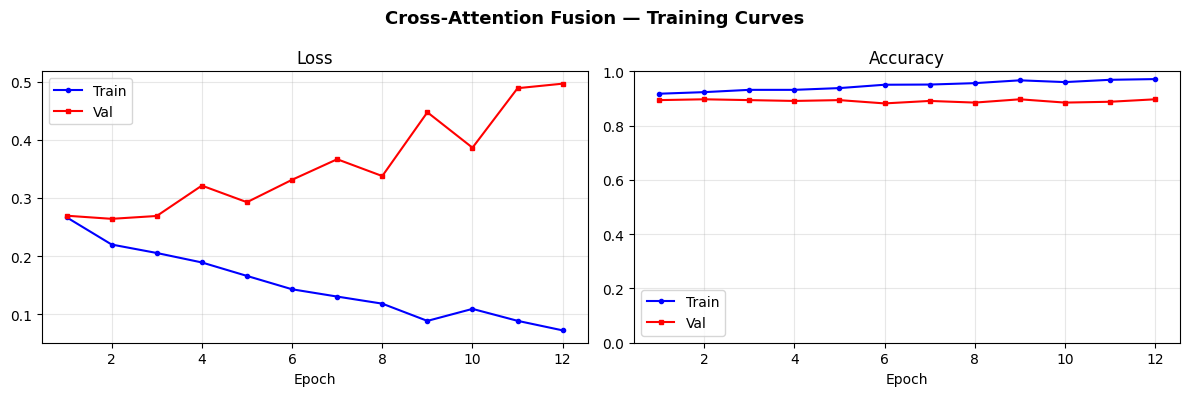

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['tr_loss']) + 1)

axes[0].plot(ep, history['tr_loss'], 'b-o', label='Train', markersize=3)
axes[0].plot(ep, history['va_loss'], 'r-s', label='Val',   markersize=3)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['tr_acc'], 'b-o', label='Train', markersize=3)
axes[1].plot(ep, history['va_acc'], 'r-s', label='Val',   markersize=3)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])

plt.suptitle('Cross-Attention Fusion — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fusion_training_curves.png', dpi=150)
plt.show()

## 6. 테스트 성능 평가

In [35]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for v, t, a, y in test_loader:
        v, t, a = v.to(device), t.to(device), a.to(device)
        logits = model(v, t, a)
        preds  = logits.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_targets.extend(y.tolist())

test_acc = accuracy_score(all_targets, all_preds)
test_f1  = f1_score(all_targets, all_preds, average='macro')

print(f'=== Test 결과 ===')
print(f'Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Macro F1 : {test_f1:.4f}')
print()
print(classification_report(all_targets, all_preds, target_names=['Negative(0)', 'Positive(1)']))

=== Test 결과 ===
Accuracy : 0.8758 (87.58%)
Macro F1 : 0.8754

              precision    recall  f1-score   support

 Negative(0)       0.85      0.91      0.88       168
 Positive(1)       0.90      0.84      0.87       162

    accuracy                           0.88       330
   macro avg       0.88      0.88      0.88       330
weighted avg       0.88      0.88      0.88       330



## 7. Confusion Matrix & 모달리티별 기여도 분석

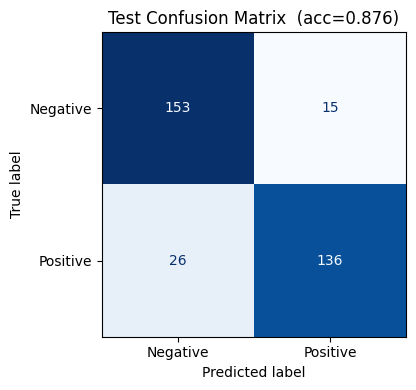

저장: fusion_confusion_matrix.png


In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Test Confusion Matrix  (acc={test_acc:.3f})')
plt.tight_layout()
plt.savefig('fusion_confusion_matrix.png', dpi=150)
plt.show()
print('저장: fusion_confusion_matrix.png')

=== Ablation Study (Test Accuracy) ===
  All modalities (full)                    0.8758  ██████████████████████████
  Text + Audio (Video masked)              0.8758  ██████████████████████████
  Video + Audio (Text masked)              0.7364  ██████████████████████
  Video + Text (Audio masked)              0.8697  ██████████████████████████
  Audio only                               0.7182  █████████████████████
  Text only                                0.8697  ██████████████████████████
  Video only                               0.5970  █████████████████


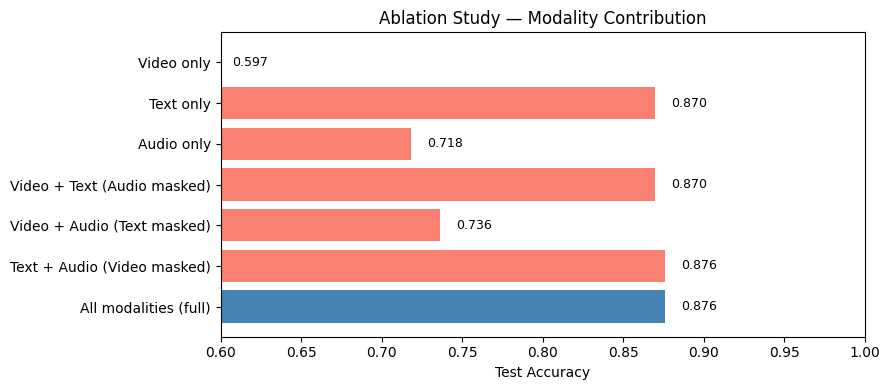

저장: fusion_ablation.png


In [37]:
# ── 모달리티 ablation (단일 모달리티 제로-마스킹) ───────────────────────────────
def eval_with_mask(loader, mask_v=False, mask_t=False, mask_a=False):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for v, t, a, y in loader:
            v, t, a = v.to(device), t.to(device), a.to(device)
            if mask_v: v = torch.zeros_like(v)
            if mask_t: t = torch.zeros_like(t)
            if mask_a: a = torch.zeros_like(a)
            logits = model(v, t, a)
            preds.extend(logits.argmax(1).cpu().tolist())
            targets.extend(y.tolist())
    return accuracy_score(targets, preds)

ablation = {
    'All modalities (full)':       eval_with_mask(test_loader),
    'Text + Audio (Video masked)': eval_with_mask(test_loader, mask_v=True),
    'Video + Audio (Text masked)': eval_with_mask(test_loader, mask_t=True),
    'Video + Text (Audio masked)': eval_with_mask(test_loader, mask_a=True),
    'Audio only':                  eval_with_mask(test_loader, mask_v=True, mask_t=True),
    'Text only':                   eval_with_mask(test_loader, mask_v=True, mask_a=True),
    'Video only':                  eval_with_mask(test_loader, mask_t=True, mask_a=True),
}

print('=== Ablation Study (Test Accuracy) ===')
for name, acc in ablation.items():
    bar = '█' * int(acc * 30)
    print(f'  {name:<40} {acc:.4f}  {bar}')

# 시각화
fig, ax = plt.subplots(figsize=(9, 4))
names = list(ablation.keys())
accs  = list(ablation.values())
colors = ['steelblue' if i == 0 else 'salmon' for i in range(len(names))]
bars = ax.barh(names, accs, color=colors)
ax.set_xlim(0.6, 1.0)
ax.set_xlabel('Test Accuracy')
ax.set_title('Ablation Study — Modality Contribution')
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fusion_ablation.png', dpi=150)
plt.show()
print('저장: fusion_ablation.png')

## 8. 모델 저장

In [38]:
torch.save({
    'model_state_dict': model.state_dict(),
    'test_acc':  test_acc,
    'test_f1':   test_f1,
    'val_acc':   early_stop.best_acc,
    'config': {'feat_dim': 256, 'num_heads': 4, 'dropout': 0.2},
}, 'cross_attn_fusion_best.pt')

print('모델 저장 완료: cross_attn_fusion_best.pt')
print(f'\n최종 성능 요약')
print(f'  Val  Accuracy : {early_stop.best_acc:.4f}')
print(f'  Test Accuracy : {test_acc:.4f}')
print(f'  Test Macro F1 : {test_f1:.4f}')

모델 저장 완료: cross_attn_fusion_best.pt

최종 성능 요약
  Val  Accuracy : 0.8970
  Test Accuracy : 0.8758
  Test Macro F1 : 0.8754


---
## 9. 오류 샘플 분석 (Error Analysis)

모델이 틀린 샘플의 **ID**, **텍스트**, **얼굴 이미지**, **오디오**를 직접 확인한다.

> 경로 설정만 맞추면 아래 세 셀이 순서대로 동작한다.

In [ ]:
import pandas as pd, os

# ── 경로 설정 ──────────────────────────────────────────────────────────────────
DATA_ROOT      = 'data'
LABEL_CSV      = f'{DATA_ROOT}/mosi_text_metadata.csv'
VIDEO_PKL_RAW  = f'{DATA_ROOT}/video_preprocessed.pkl'
AUDIO_DIR      = f'{DATA_ROOT}/Audio'
TRANSCRIPT_DIR = f'{DATA_ROOT}/Transcript/Segmented'

# ── .annotprocessed 파서 ───────────────────────────────────────────────────────
# 포맷: {seg_idx}_DELIM_ text   예) 14_DELIM_ FOR ALL OF THOSE PEOPLE ...
def parse_annotprocessed(video_id, seg_idx):
    path = os.path.join(TRANSCRIPT_DIR, f'{video_id}.annotprocessed')
    if not os.path.exists(path):
        return '(파일 없음)'
    target_prefix = f'{seg_idx}_DELIM_'
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line.startswith(target_prefix):
                return line[len(target_prefix):].strip()
    return '(seg_idx 없음)'

# ── label_df 로드 ──────────────────────────────────────────────────────────────
label_df = pd.read_csv(LABEL_CSV)
label_df['sample_id'] = label_df['video_id'].astype(str) + '_' + label_df['seg_idx'].astype(str)
label_df = label_df.reset_index(drop=True)

# ── 오류 샘플 추출 ─────────────────────────────────────────────────────────────
wrong_local  = np.where(np.array(all_preds) != np.array(all_targets))[0]
wrong_global = te_idx[wrong_local]

transcripts = [
    parse_annotprocessed(label_df.loc[g, 'video_id'], label_df.loc[g, 'seg_idx'])
    for g in wrong_global
]

wrong_df = pd.DataFrame({
    'sample_id'  : label_df.loc[wrong_global, 'sample_id'].values,
    'video_id'   : label_df.loc[wrong_global, 'video_id'].values,
    'seg_idx'    : label_df.loc[wrong_global, 'seg_idx'].values,
    'true_label' : ['Pos' if t==1 else 'Neg' for t in np.array(all_targets)[wrong_local]],
    'pred_label' : ['Pos' if p==1 else 'Neg' for p in np.array(all_preds)[wrong_local]],
    'transcript' : transcripts,
    'global_idx' : wrong_global,
}).reset_index(drop=True)

print(f'오류 샘플: {len(wrong_df)}개 / {len(te_idx)}개 ({len(wrong_df)/len(te_idx)*100:.1f}%)')
print(f'  FP (Neg→Pos): {((wrong_df.true_label=="Neg") & (wrong_df.pred_label=="Pos")).sum()}개')
print(f'  FN (Pos→Neg): {((wrong_df.true_label=="Pos") & (wrong_df.pred_label=="Neg")).sum()}개\n')

pd.set_option('display.max_colwidth', 90)
display(wrong_df[['sample_id', 'true_label', 'pred_label', 'transcript']])

In [ ]:
# ── 얼굴 이미지 그리드 ────────────────────────────────────────────────────────
with open(VIDEO_PKL_RAW, 'rb') as f:
    raw = pickle.load(f)

# pkl 구조 자동 감지
if isinstance(raw, dict):
    img_key = next(k for k in raw if 'feat' not in k.lower() and 'label' not in k.lower())
    raw_images = raw[img_key]         # numpy array (N, H, W, 3)
elif isinstance(raw, (list, tuple)) and len(raw) == 2:
    raw_images = raw[0]               # (images, labels) 튜플
else:
    raw_images = raw

raw_images = np.array(raw_images)    # 확실히 numpy로
print(f'raw_images shape: {raw_images.shape}  dtype: {raw_images.dtype}')

# ── 그리드 출력 ────────────────────────────────────────────────────────────────
N_SHOW = min(40, len(wrong_df))
COLS   = 8
ROWS   = (N_SHOW + COLS - 1) // COLS

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 2, ROWS * 2.3))
axes = axes.flatten()

for i in range(N_SHOW):
    row  = wrong_df.iloc[i]
    gidx = int(row['global_idx'])
    img  = raw_images[gidx]

    ax = axes[i]
    ax.imshow(img)
    ax.axis('off')
    color = 'crimson' if row['true_label'] == 'Pos' else 'steelblue'
    ax.set_title(
        f"{row['sample_id']}\n실제:{row['true_label']} 예측:{row['pred_label']}",
        fontsize=6.5, color=color, pad=2
    )

for j in range(N_SHOW, len(axes)):
    axes[j].axis('off')

plt.suptitle('오류 샘플 얼굴 이미지 (빨강=실제Pos / 파랑=실제Neg)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('error_faces.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: error_faces.png  ({N_SHOW}장)')

In [51]:
import IPython.display as ipd
import librosa, librosa.display

# ── 오디오 파일 경로 탐색 함수 ─────────────────────────────────────────────────
def find_audio(video_id, seg_idx):
    """data/Audio 하위에서 {video_id}_{seg_idx}.wav 탐색."""
    candidates = [
        os.path.join(AUDIO_DIR, f'{video_id}_{seg_idx}.wav'),
        os.path.join(AUDIO_DIR, video_id, f'{video_id}_{seg_idx}.wav'),
        os.path.join(AUDIO_DIR, 'Segmented', f'{video_id}_{seg_idx}.wav'),
        os.path.join(AUDIO_DIR, video_id, f'{video_id}_{seg_idx}.mp3'),
    ]
    return next((p for p in candidates if os.path.exists(p)), None)

# ── 오디오 재생 + 파형 시각화 ─────────────────────────────────────────────────
N_AUDIO = min(10, len(wrong_df))

for i in range(N_AUDIO):
    row = wrong_df.iloc[i]
    wav_path = find_audio(row['video_id'], row['seg_idx'])

    print(f'─── [{i+1}/{N_AUDIO}]  {row["sample_id"]}  '
          f'실제: {row["true_label"]}  예측: {row["pred_label"]}')
    print(f'     {row["transcript"]}')

    if wav_path:
        y_wav, sr = librosa.load(wav_path, sr=None)
        fig, ax = plt.subplots(figsize=(9, 1.6))
        librosa.display.waveshow(y_wav, sr=sr, ax=ax, color='steelblue', alpha=0.8)
        ax.set_title(f'{row["sample_id"]}  실제:{row["true_label"]}  예측:{row["pred_label"]}',
                     fontsize=9)
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
        plt.tight_layout(); plt.show()
        display(ipd.Audio(wav_path))
    else:
        print(f'     ⚠ 오디오 파일 없음')
    print()

ModuleNotFoundError: No module named 'librosa'